<a href="https://colab.research.google.com/github/rohaan2614/Federated_Learning/blob/master/FedAvg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup and Data Preparation

In [26]:
!pip install torch torchvision

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

# Configuration
BATCH_SIZE = 32
NUM_CLIENTS = 3
CLIENTS_PER_ROUND = 2  # Number of clients participating per round
LOCAL_EPOCHS = 1  # Local epochs
GLOBAL_ROUNDS = 10  # Number of global rounds

# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split dataset among clients
client_datasets = torch.utils.data.random_split(train_dataset, [len(train_dataset)//NUM_CLIENTS]*NUM_CLIENTS)
client_loaders = [DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True) for dataset in client_datasets]

# Download and load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Model Definition

In [28]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64*24*24, 128)  # Adjusted based on actual output size
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(-1, 64*24*24)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate model
global_model = SimpleCNN()

### Federated Learning Framework

In [29]:
# Define client update function
def client_update(client_model, train_loader, criterion, optimizer, epochs=1):
    client_model.train()
    total_loss = 0.0
    num_batches = 0

    for epoch in range(epochs):
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = client_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    return client_model.state_dict(), avg_loss

In [30]:
# Define FedAvg aggregation function
def average_weights(global_model, client_weights):
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = torch.stack([client_weights[i][key] for i in range(len(client_weights))], 0).mean(0)
    global_model.load_state_dict(global_dict)

In [31]:
# Define evaluation function
def evaluate(model, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = val_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

### Train & Evaluate

In [33]:
import random

# Define federated training function
def train_federated(global_model, client_loaders, test_loader, criterion, optimizer_cls, num_clients, clients_per_round, epochs=1, num_global_rounds=10):
    # Lists to store the metrics
    global_val_losses = []
    global_val_accuracies = []
    global_train_losses = []

    for global_round in range(num_global_rounds):
        print(f'Global Round {global_round+1}/{num_global_rounds}')

        # Randomly select clients for this round
        selected_clients = random.sample(range(num_clients), clients_per_round)

        client_weights = []
        global_round_train_loss = 0.0

        for client_id in selected_clients:
            client_model = SimpleCNN()
            client_model.load_state_dict(global_model.state_dict())
            optimizer = optimizer_cls(client_model.parameters())

            client_weight, client_train_loss = client_update(client_model, client_loaders[client_id], criterion, optimizer, epochs)
            client_weights.append(client_weight)
            global_round_train_loss += client_train_loss

        average_weights(global_model, client_weights)

        avg_val_loss, val_accuracy = evaluate(global_model, test_loader, criterion)
        global_train_losses.append(global_round_train_loss / len(selected_clients))
        global_val_losses.append(avg_val_loss)
        global_val_accuracies.append(val_accuracy)

        print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')
        print(f'Training Loss: {global_train_losses[-1]:.4f}')

    return global_val_losses, global_val_accuracies, global_train_losses

# Loss function
criterion = nn.CrossEntropyLoss()

# Train the global model using federated learning
global_val_losses, global_val_accuracies, global_train_losses = train_federated(global_model, client_loaders, test_loader, criterion, lambda params: optim.Adam(params, lr=0.001), NUM_CLIENTS, CLIENTS_PER_ROUND, LOCAL_EPOCHS, GLOBAL_ROUNDS)

Global Round 1/10
Validation Loss: 0.0859, Validation Accuracy: 0.9753
Training Loss: 0.1918
Global Round 2/10
Validation Loss: 0.0385, Validation Accuracy: 0.9873
Training Loss: 0.0774
Global Round 3/10
Validation Loss: 0.0343, Validation Accuracy: 0.9901
Training Loss: 0.0518
Global Round 4/10
Validation Loss: 0.0390, Validation Accuracy: 0.9874
Training Loss: 0.0366
Global Round 5/10
Validation Loss: 0.0299, Validation Accuracy: 0.9907
Training Loss: 0.0307
Global Round 6/10
Validation Loss: 0.0370, Validation Accuracy: 0.9885
Training Loss: 0.0188
Global Round 7/10
Validation Loss: 0.0391, Validation Accuracy: 0.9899
Training Loss: 0.0149
Global Round 8/10
Validation Loss: 0.0351, Validation Accuracy: 0.9902
Training Loss: 0.0168
Global Round 9/10
Validation Loss: 0.0392, Validation Accuracy: 0.9895
Training Loss: 0.0117
Global Round 10/10
Validation Loss: 0.0439, Validation Accuracy: 0.9909
Training Loss: 0.0126


### Plotting

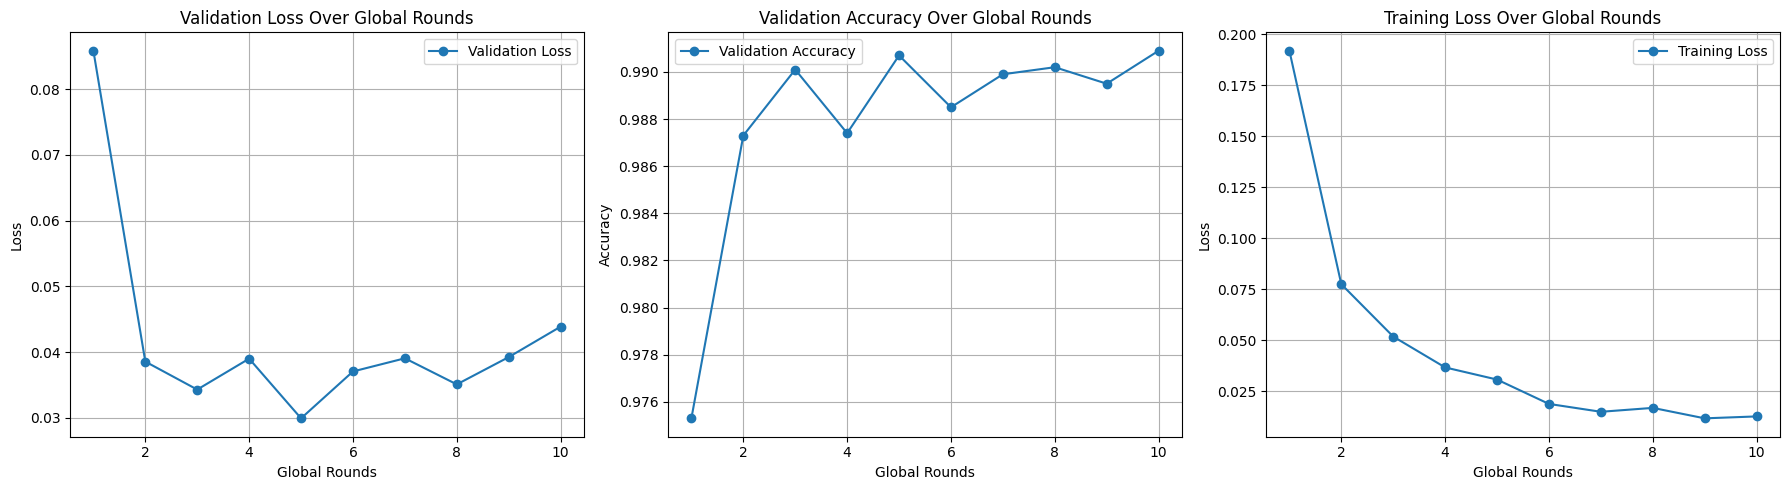

In [34]:
import matplotlib.pyplot as plt

# Function to plot metrics
def plot_metrics(global_val_losses, global_val_accuracies, global_train_losses):
    rounds = range(1, len(global_val_losses) + 1)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(rounds, global_val_losses, marker='o', label='Validation Loss')
    plt.xlabel('Global Rounds')
    plt.ylabel('Loss')
    plt.title('Validation Loss Over Global Rounds')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(rounds, global_val_accuracies, marker='o', label='Validation Accuracy')
    plt.xlabel('Global Rounds')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy Over Global Rounds')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(rounds, global_train_losses, marker='o', label='Training Loss')
    plt.xlabel('Global Rounds')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Global Rounds')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_metrics(global_val_losses, global_val_accuracies, global_train_losses)
